# 📊 RETO 6 - OPEN DATA: Exploración Dataset Principal

**Proyecto:** Observatorio de Comercio Minorista - España  
**Dataset:** Customer Shopping Dataset (Istanbul → España)  
**Autor:** Ana BM  
**Fecha:** Marzo 2026  

---

## 🎯 Objetivos de este Notebook:

1. ✅ Cargar y explorar el dataset principal de Kaggle
2. ✅ Analizar estructura, tipos de datos y calidad
3. ✅ Identificar valores nulos, duplicados y outliers
4. ✅ Explorar distribuciones de variables clave
5. ✅ Preparar mapeo Istanbul → España
6. ✅ Documentar hallazgos para el informe final

---

## 📦 CELDA 1: Importar Librerías

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")
print(f"📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías importadas correctamente
📅 Fecha de ejecución: 2026-03-17 20:26:51


## 🔌 CELDA 2: Montar Google Drive y Cargar Dataset

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Google Drive montado correctamente")

Mounted at /content/drive

✅ Google Drive montado correctamente


In [3]:
# Cargar dataset principal
ruta_csv = '/content/drive/MyDrive/Reto-6-Open-Data/data/raw/customer_shopping_data.csv'

try:
    df = pd.read_csv(ruta_csv)
    print("✅ Dataset cargado correctamente")
    print(f"📊 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
except FileNotFoundError:
    print("❌ ERROR: No se encontró el archivo CSV")
    print("Verifica la ruta en Google Drive")

✅ Dataset cargado correctamente
📊 Dimensiones: 99,457 filas x 10 columnas


## 🔍 CELDA 3: Información General del Dataset

In [4]:
print("="*80)
print("📋 INFORMACIÓN GENERAL DEL DATASET")
print("="*80)

print("\n🔢 DIMENSIONES:")
print(f"   • Total de registros: {df.shape[0]:,}")
print(f"   • Total de columnas: {df.shape[1]}")

print("\n📊 INFORMACIÓN DE COLUMNAS:")
df.info()

print("\n📝 NOMBRES DE COLUMNAS:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

📋 INFORMACIÓN GENERAL DEL DATASET

🔢 DIMENSIONES:
   • Total de registros: 99,457
   • Total de columnas: 10

📊 INFORMACIÓN DE COLUMNAS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB

📝 NOMBRES DE COLUMNAS:
   1. invoice_no
   2. customer_id
   3. gender
   4. age
   5. category
   6. quantity
   7. price
   8. payment_method
   9. i

## 👀 CELDA 4: Primeras y Últimas Filas

In [5]:
print("🔝 PRIMERAS 5 FILAS:")
print("="*80)
display(df.head())

print("\n🔚 ÚLTIMAS 5 FILAS:")
print("="*80)
display(df.tail())

🔝 PRIMERAS 5 FILAS:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon



🔚 ÚLTIMAS 5 FILAS:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park
99456,I232867,C273973,Female,36,Souvenir,3,35.19,Credit Card,15/10/2022,Mall of Istanbul


## 📈 CELDA 5: Estadísticas Descriptivas

In [6]:
print("📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)
display(df.describe())

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("="*80)
display(df.describe(include='object'))

📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000



📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS


,invoice_no,customer_id,gender,category,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457,99457,99457,99457
unique,99457,99457,2,8,3,797,10
top,I232867,C273973,Female,Clothing,Cash,24/11/2021,Mall of Istanbul
freq,1,1,59482,34487,44447,159,19943


## 🧹 CELDA 6: Análisis de Calidad de Datos

In [7]:
print("="*80)
print("🔍 ANÁLISIS DE CALIDAD DE DATOS")
print("="*80)

# 1. VALORES NULOS
print("\n1️⃣ VALORES NULOS POR COLUMNA:")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
calidad_df = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})
print(calidad_df[calidad_df['Valores Nulos'] > 0])

if nulos.sum() == 0:
    print("   ✅ No hay valores nulos en el dataset")

# 2. DUPLICADOS
print("\n2️⃣ REGISTROS DUPLICADOS:")
duplicados = df.duplicated().sum()
print(f"   • Total duplicados: {duplicados:,}")
print(f"   • Porcentaje: {(duplicados/len(df)*100):.2f}%")

if duplicados == 0:
    print("   ✅ No hay registros duplicados")

# 3. TIPOS DE DATOS
print("\n3️⃣ TIPOS DE DATOS:")
print(df.dtypes)

🔍 ANÁLISIS DE CALIDAD DE DATOS

1️⃣ VALORES NULOS POR COLUMNA:
Empty DataFrame
Columns: [Valores Nulos, Porcentaje (%)]
Index: []
   ✅ No hay valores nulos en el dataset

2️⃣ REGISTROS DUPLICADOS:
   • Total duplicados: 0
   • Porcentaje: 0.00%
   ✅ No hay registros duplicados

3️⃣ TIPOS DE DATOS:
invoice_no         object
customer_id        object
gender             object
age                 int64
category           object
quantity            int64
price             float64
payment_method     object
invoice_date       object
shopping_mall      object
dtype: object


## 📅 CELDA 7: Análisis Temporal

📅 ANÁLISIS TEMPORAL

📊 PERÍODO TEMPORAL:
   • Fecha mínima: 2021-01-01
   • Fecha máxima: 2023-03-08
   • Rango: 796 días

📊 DISTRIBUCIÓN POR AÑO:
year
2021    45382
2022    45551
2023     8524
Name: count, dtype: int64

📊 DISTRIBUCIÓN POR MES:
month_name
January      11608
February     10482
March         8730
July          7877
October       7764
May           7697
December      7680
August        7635
June          7581
November      7563
April         7487
September     7353
Name: count, dtype: int64


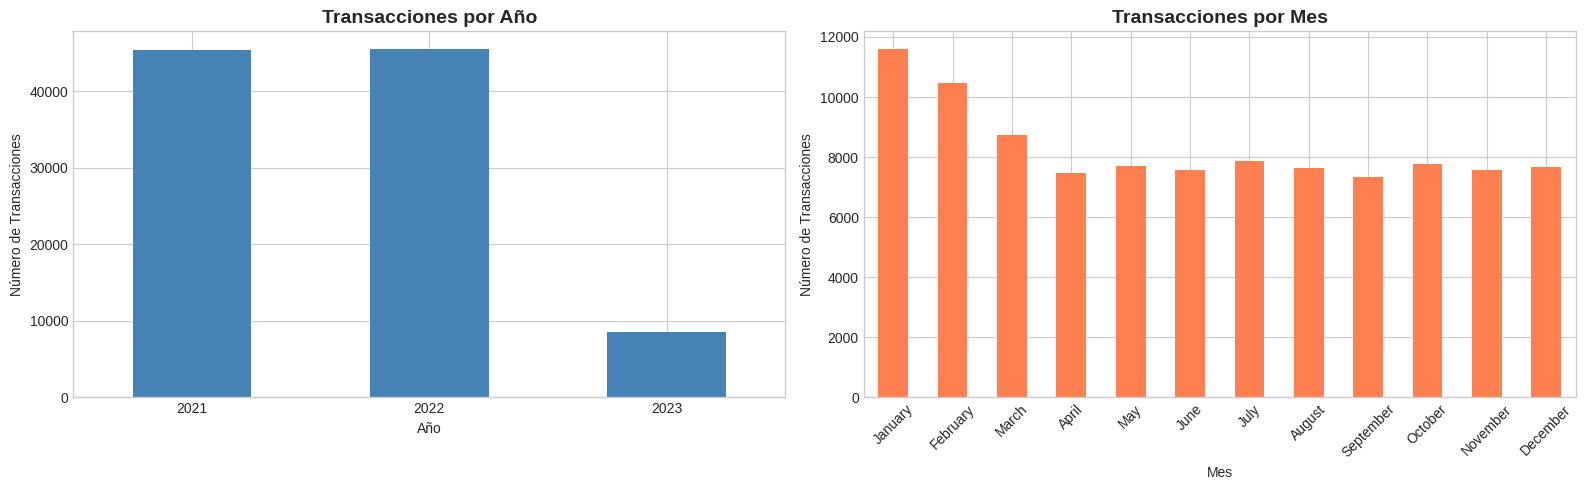


✅ Análisis temporal completado


In [8]:
print("="*80)
print("📅 ANÁLISIS TEMPORAL")
print("="*80)

# Convertir a datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

# Crear variables temporales auxiliares
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['month_name'] = df['invoice_date'].dt.month_name()
df['day_of_week'] = df['invoice_date'].dt.day_name()

print("\n📊 PERÍODO TEMPORAL:")
print(f"   • Fecha mínima: {df['invoice_date'].min().strftime('%Y-%m-%d')}")
print(f"   • Fecha máxima: {df['invoice_date'].max().strftime('%Y-%m-%d')}")
print(f"   • Rango: {(df['invoice_date'].max() - df['invoice_date'].min()).days} días")

print("\n📊 DISTRIBUCIÓN POR AÑO:")
print(df['year'].value_counts().sort_index())

print("\n📊 DISTRIBUCIÓN POR MES:")
print(df['month_name'].value_counts())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Transacciones por año
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transacciones por Año', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de Transacciones')
axes[0].tick_params(axis='x', rotation=0)

# Transacciones por mes
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['month_name'].value_counts().reindex(month_order)
month_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Transacciones por Mes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Número de Transacciones')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Análisis temporal completado")

## 🛍️ CELDA 8: Análisis de Categorías de Productos

🛍️ ANÁLISIS DE CATEGORÍAS DE PRODUCTOS

📊 CATEGORÍAS ÚNICAS:
   • Total de categorías: 8
   • Categorías: Clothing, Shoes, Books, Cosmetics, Food & Beverage, Toys, Technology, Souvenir

📊 DISTRIBUCIÓN DE TRANSACCIONES POR CATEGORÍA:
                 Transacciones  Porcentaje (%)
category                                      
Clothing                 34487           34.68
Cosmetics                15097           15.18
Food & Beverage          14776           14.86
Toys                     10087           10.14
Shoes                    10034           10.09
Souvenir                  4999            5.03
Technology                4996            5.02
Books                     4981            5.01


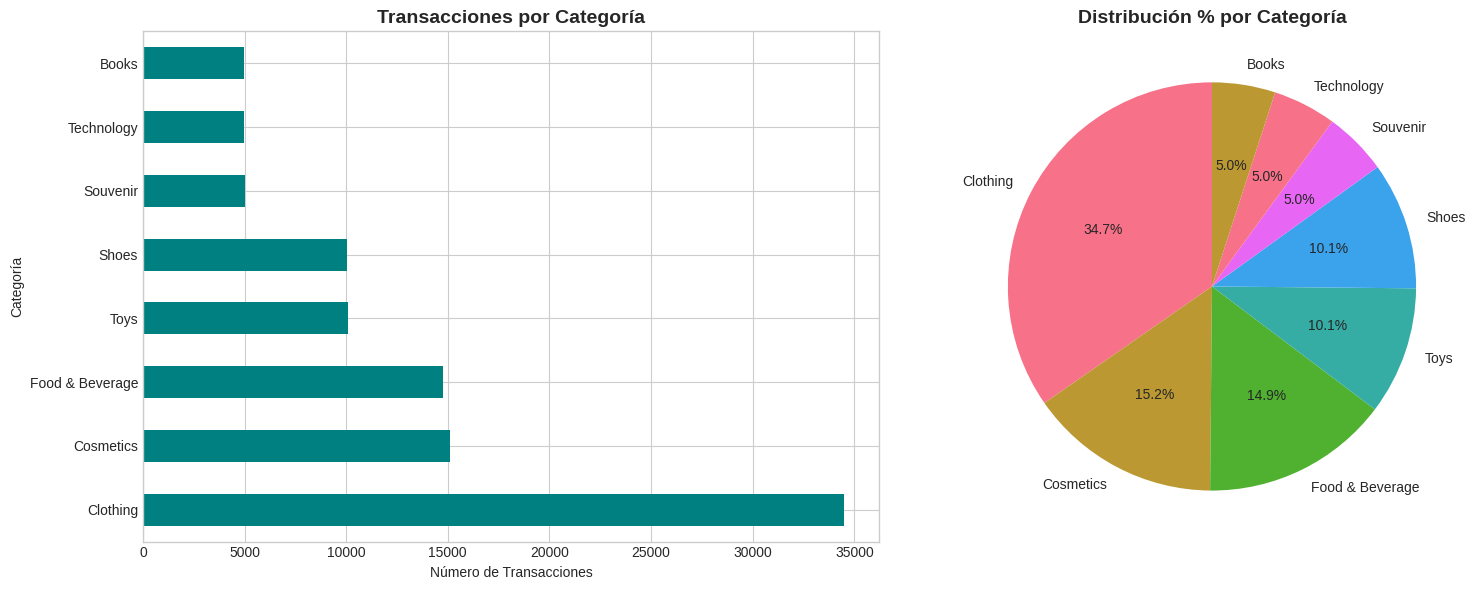


✅ Análisis de categorías completado


In [9]:
print("="*80)
print("🛍️ ANÁLISIS DE CATEGORÍAS DE PRODUCTOS")
print("="*80)

print("\n📊 CATEGORÍAS ÚNICAS:")
categorias = df['category'].unique()
print(f"   • Total de categorías: {len(categorias)}")
print(f"   • Categorías: {', '.join(categorias)}")

print("\n📊 DISTRIBUCIÓN DE TRANSACCIONES POR CATEGORÍA:")
cat_counts = df['category'].value_counts()
cat_pct = (cat_counts / len(df) * 100).round(2)
cat_df = pd.DataFrame({
    'Transacciones': cat_counts,
    'Porcentaje (%)': cat_pct
})
print(cat_df)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
cat_counts.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Transacciones por Categoría', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Transacciones')
axes[0].set_ylabel('Categoría')

# Gráfico de pastel
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribución % por Categoría', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Análisis de categorías completado")

## 🏬 CELDA 9: Análisis de Shopping Malls (Para Mapeo España)

🏬 ANÁLISIS DE SHOPPING MALLS - MAPEO ISTANBUL → ESPAÑA

📊 SHOPPING MALLS ÚNICOS:
   • Total de centros comerciales: 10

📊 DISTRIBUCIÓN DE TRANSACCIONES POR MALL:
Shopping Mall (Istanbul)  Transacciones  Porcentaje (%)
        Mall of Istanbul          19943           20.05
                  Kanyon          19823           19.93
               Metrocity          15011           15.09
            Metropol AVM          10161           10.22
            Istinye Park           9781            9.83
            Zorlu Center           5075            5.10
             Cevahir AVM           4991            5.02
          Forum Istanbul           4947            4.97
          Viaport Outlet           4914            4.94
       Emaar Square Mall           4811            4.84

🇪🇸 MAPEO PROPUESTO ISTANBUL → ESPAÑA:
Shopping Mall (Istanbul)   Ciudad (España)
        Mall of Istanbul            Madrid
            Istinye Park         Barcelona
                  Kanyon          Valencia
           

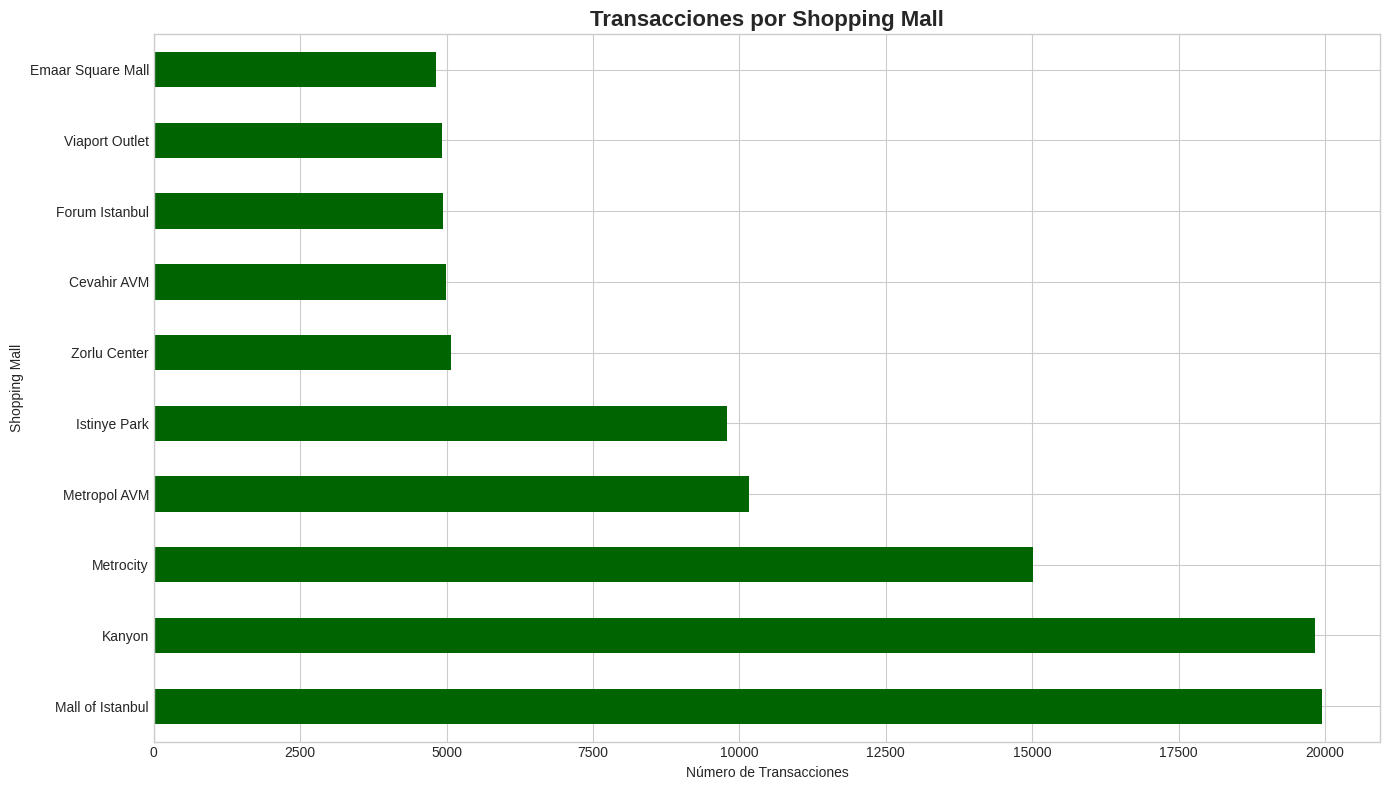


✅ Análisis de shopping malls completado


In [10]:
print("="*80)
print("🏬 ANÁLISIS DE SHOPPING MALLS - MAPEO ISTANBUL → ESPAÑA")
print("="*80)

print("\n📊 SHOPPING MALLS ÚNICOS:")
malls = df['shopping_mall'].unique()
print(f"   • Total de centros comerciales: {len(malls)}")

print("\n📊 DISTRIBUCIÓN DE TRANSACCIONES POR MALL:")
mall_counts = df['shopping_mall'].value_counts()
mall_pct = (mall_counts / len(df) * 100).round(2)
mall_df = pd.DataFrame({
    'Shopping Mall (Istanbul)': mall_counts.index,
    'Transacciones': mall_counts.values,
    'Porcentaje (%)': mall_pct.values
})
print(mall_df.to_string(index=False))

print("\n🇪🇸 MAPEO PROPUESTO ISTANBUL → ESPAÑA:")
print("="*80)

# Tabla de mapeo (ajustar según los malls reales del dataset)
mapeo = {
    'Mall of Istanbul': 'Madrid',
    'Istinye Park': 'Barcelona',
    'Kanyon': 'Valencia',
    'Metrocity': 'Sevilla',
    'Metropol AVM': 'Bilbao',
    'Cevahir AVM': 'Zaragoza',
    'Forum Istanbul': 'Málaga',
    'Viaport Outlet': 'Alicante',
    'Zorlu Center': 'Palma de Mallorca',
    'History Island': 'Las Palmas'
}

mapeo_df = pd.DataFrame(list(mapeo.items()),
                        columns=['Shopping Mall (Istanbul)', 'Ciudad (España)'])
print(mapeo_df.to_string(index=False))

# Visualización
plt.figure(figsize=(14, 8))
mall_counts.plot(kind='barh', color='darkgreen')
plt.title('Transacciones por Shopping Mall', fontsize=16, fontweight='bold')
plt.xlabel('Número de Transacciones')
plt.ylabel('Shopping Mall')
plt.tight_layout()
plt.show()

print("\n✅ Análisis de shopping malls completado")

## 💳 CELDA 10: Análisis de Métodos de Pago

💳 ANÁLISIS DE MÉTODOS DE PAGO

📊 DISTRIBUCIÓN DE MÉTODOS DE PAGO:
Método de Pago  Transacciones  Porcentaje (%)
          Cash          44447           44.69
   Credit Card          34931           35.12
    Debit Card          20079           20.19


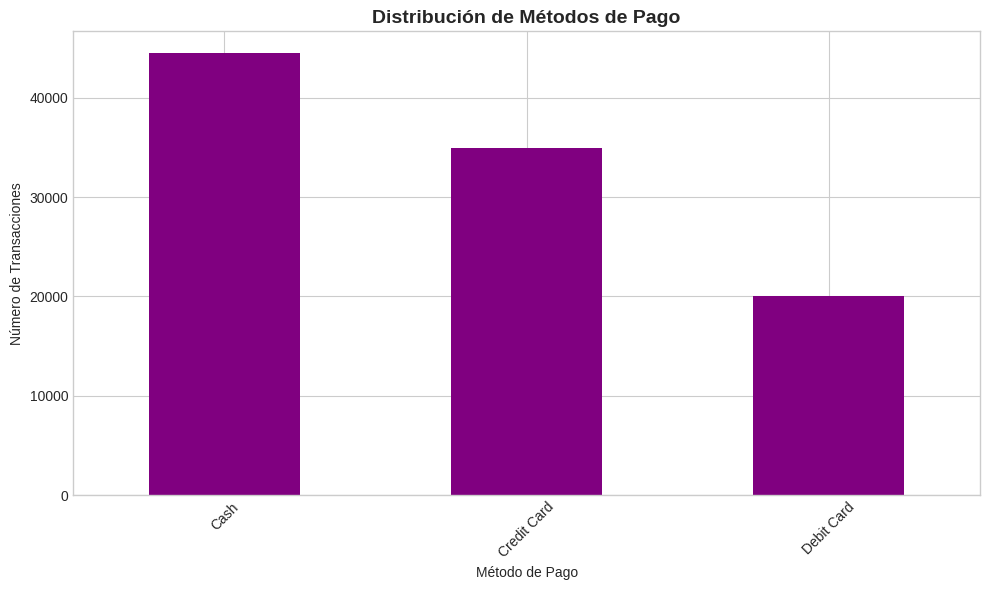


✅ Análisis de métodos de pago completado


In [11]:
print("="*80)
print("💳 ANÁLISIS DE MÉTODOS DE PAGO")
print("="*80)

print("\n📊 DISTRIBUCIÓN DE MÉTODOS DE PAGO:")
payment_counts = df['payment_method'].value_counts()
payment_pct = (payment_counts / len(df) * 100).round(2)
payment_df = pd.DataFrame({
    'Método de Pago': payment_counts.index,
    'Transacciones': payment_counts.values,
    'Porcentaje (%)': payment_pct.values
})
print(payment_df.to_string(index=False))

# Visualización
plt.figure(figsize=(10, 6))
payment_counts.plot(kind='bar', color='purple')
plt.title('Distribución de Métodos de Pago', fontsize=14, fontweight='bold')
plt.xlabel('Método de Pago')
plt.ylabel('Número de Transacciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Análisis de métodos de pago completado")

## 👥 CELDA 11: Análisis Demográfico (Género y Edad)

👥 ANÁLISIS DEMOGRÁFICO

1️⃣ DISTRIBUCIÓN POR GÉNERO:
Género  Transacciones  Porcentaje (%)
Female          59482           59.81
  Male          39975           40.19

2️⃣ ESTADÍSTICAS DE EDAD:
   • Edad mínima: 18 años
   • Edad máxima: 69 años
   • Edad promedio: 43.4 años
   • Edad mediana: 43 años


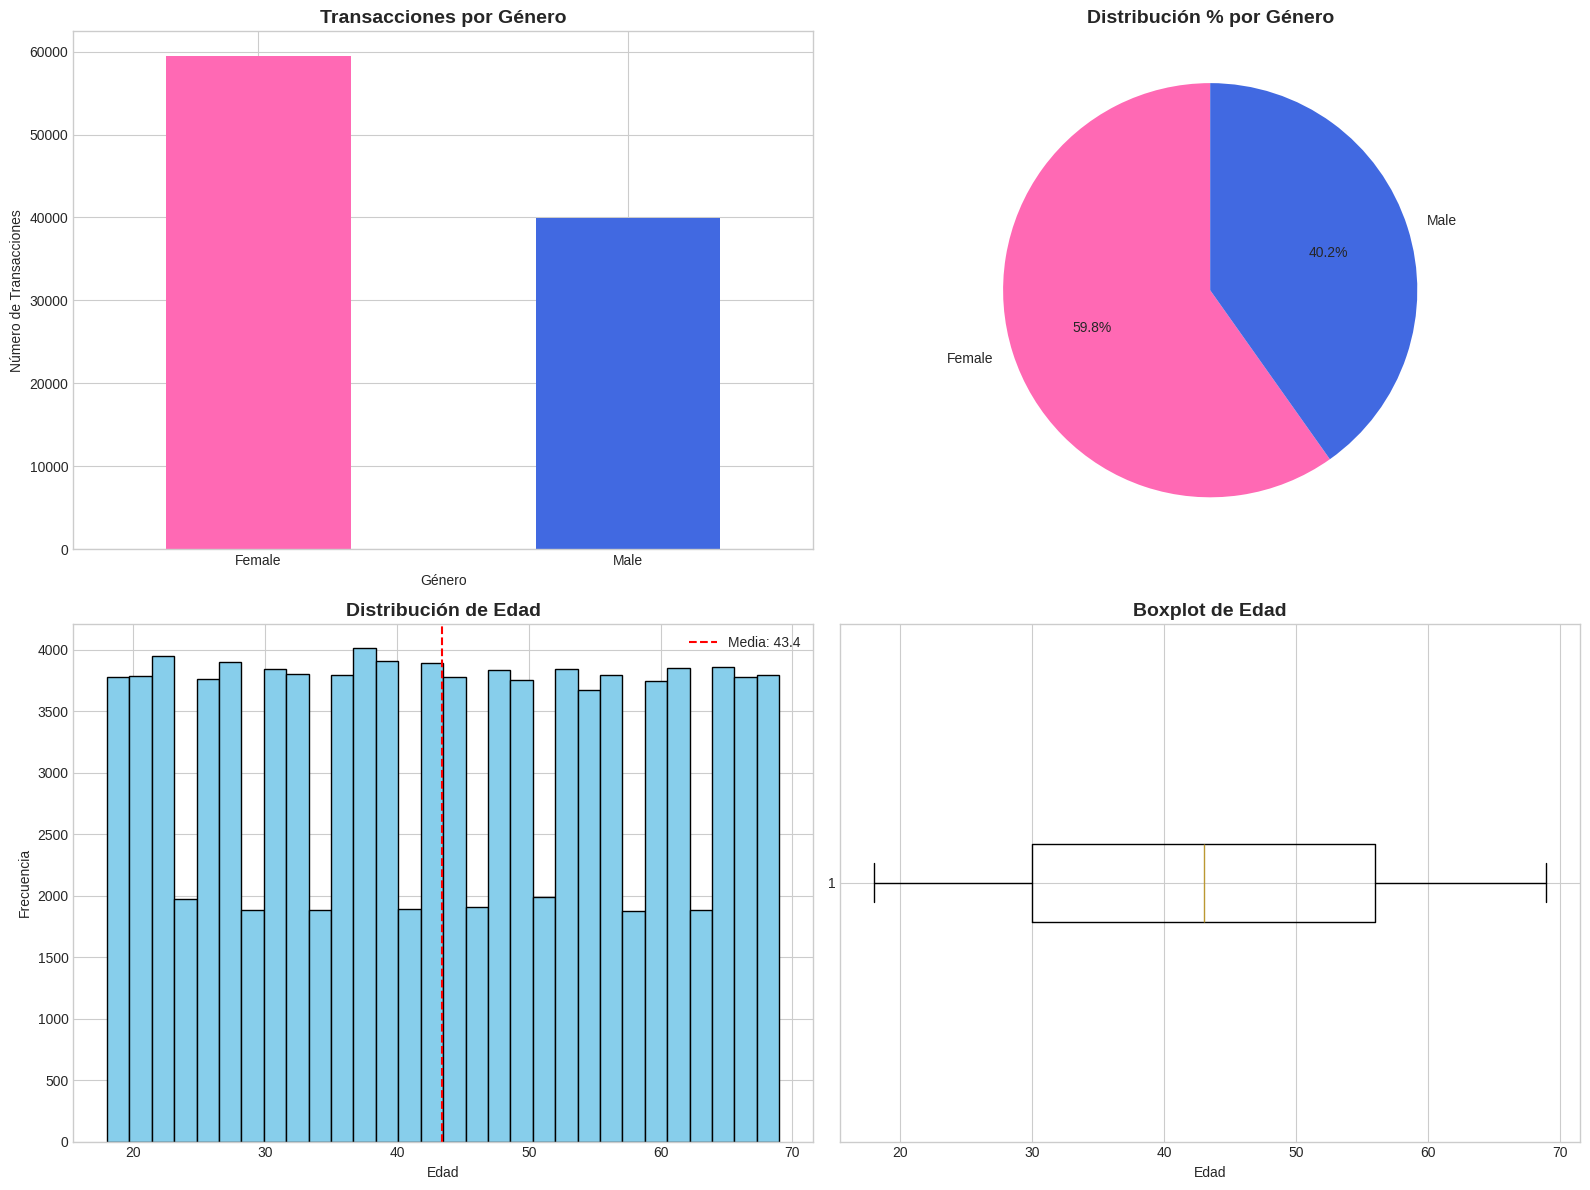


✅ Análisis demográfico completado


In [12]:
print("="*80)
print("👥 ANÁLISIS DEMOGRÁFICO")
print("="*80)

# 1. GÉNERO
print("\n1️⃣ DISTRIBUCIÓN POR GÉNERO:")
gender_counts = df['gender'].value_counts()
gender_pct = (gender_counts / len(df) * 100).round(2)
gender_df = pd.DataFrame({
    'Género': gender_counts.index,
    'Transacciones': gender_counts.values,
    'Porcentaje (%)': gender_pct.values
})
print(gender_df.to_string(index=False))

# 2. EDAD
print("\n2️⃣ ESTADÍSTICAS DE EDAD:")
print(f"   • Edad mínima: {df['age'].min()} años")
print(f"   • Edad máxima: {df['age'].max()} años")
print(f"   • Edad promedio: {df['age'].mean():.1f} años")
print(f"   • Edad mediana: {df['age'].median():.0f} años")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Género - Barras
gender_counts.plot(kind='bar', ax=axes[0,0], color=['#FF69B4', '#4169E1'])
axes[0,0].set_title('Transacciones por Género', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Género')
axes[0,0].set_ylabel('Número de Transacciones')
axes[0,0].tick_params(axis='x', rotation=0)

# Género - Pastel
axes[0,1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#FF69B4', '#4169E1'], startangle=90)
axes[0,1].set_title('Distribución % por Género', fontsize=14, fontweight='bold')

# Edad - Histograma
axes[1,0].hist(df['age'], bins=30, color='skyblue', edgecolor='black')
axes[1,0].set_title('Distribución de Edad', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Edad')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].axvline(df['age'].mean(), color='red', linestyle='--', label=f"Media: {df['age'].mean():.1f}")
axes[1,0].legend()

# Edad - Boxplot
axes[1,1].boxplot(df['age'], vert=False)
axes[1,1].set_title('Boxplot de Edad', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Edad')

plt.tight_layout()
plt.show()

print("\n✅ Análisis demográfico completado")

## 💰 CELDA 12: Análisis de Precios y Cantidades

💰 ANÁLISIS DE PRECIOS Y CANTIDADES

1️⃣ ESTADÍSTICAS DE PRECIO:
   • Precio mínimo: $5.23
   • Precio máximo: $5250.00
   • Precio promedio: $689.26
   • Precio mediano: $203.30

2️⃣ ESTADÍSTICAS DE CANTIDAD:
   • Cantidad mínima: 1
   • Cantidad máxima: 5
   • Cantidad promedio: 3.00

3️⃣ PRECIO PROMEDIO POR CATEGORÍA:
category
Technology         3156.94
Shoes              1807.39
Clothing            901.08
Cosmetics           122.45
Toys                107.73
Books                45.57
Souvenir             34.89
Food & Beverage      15.67
Name: price, dtype: float64


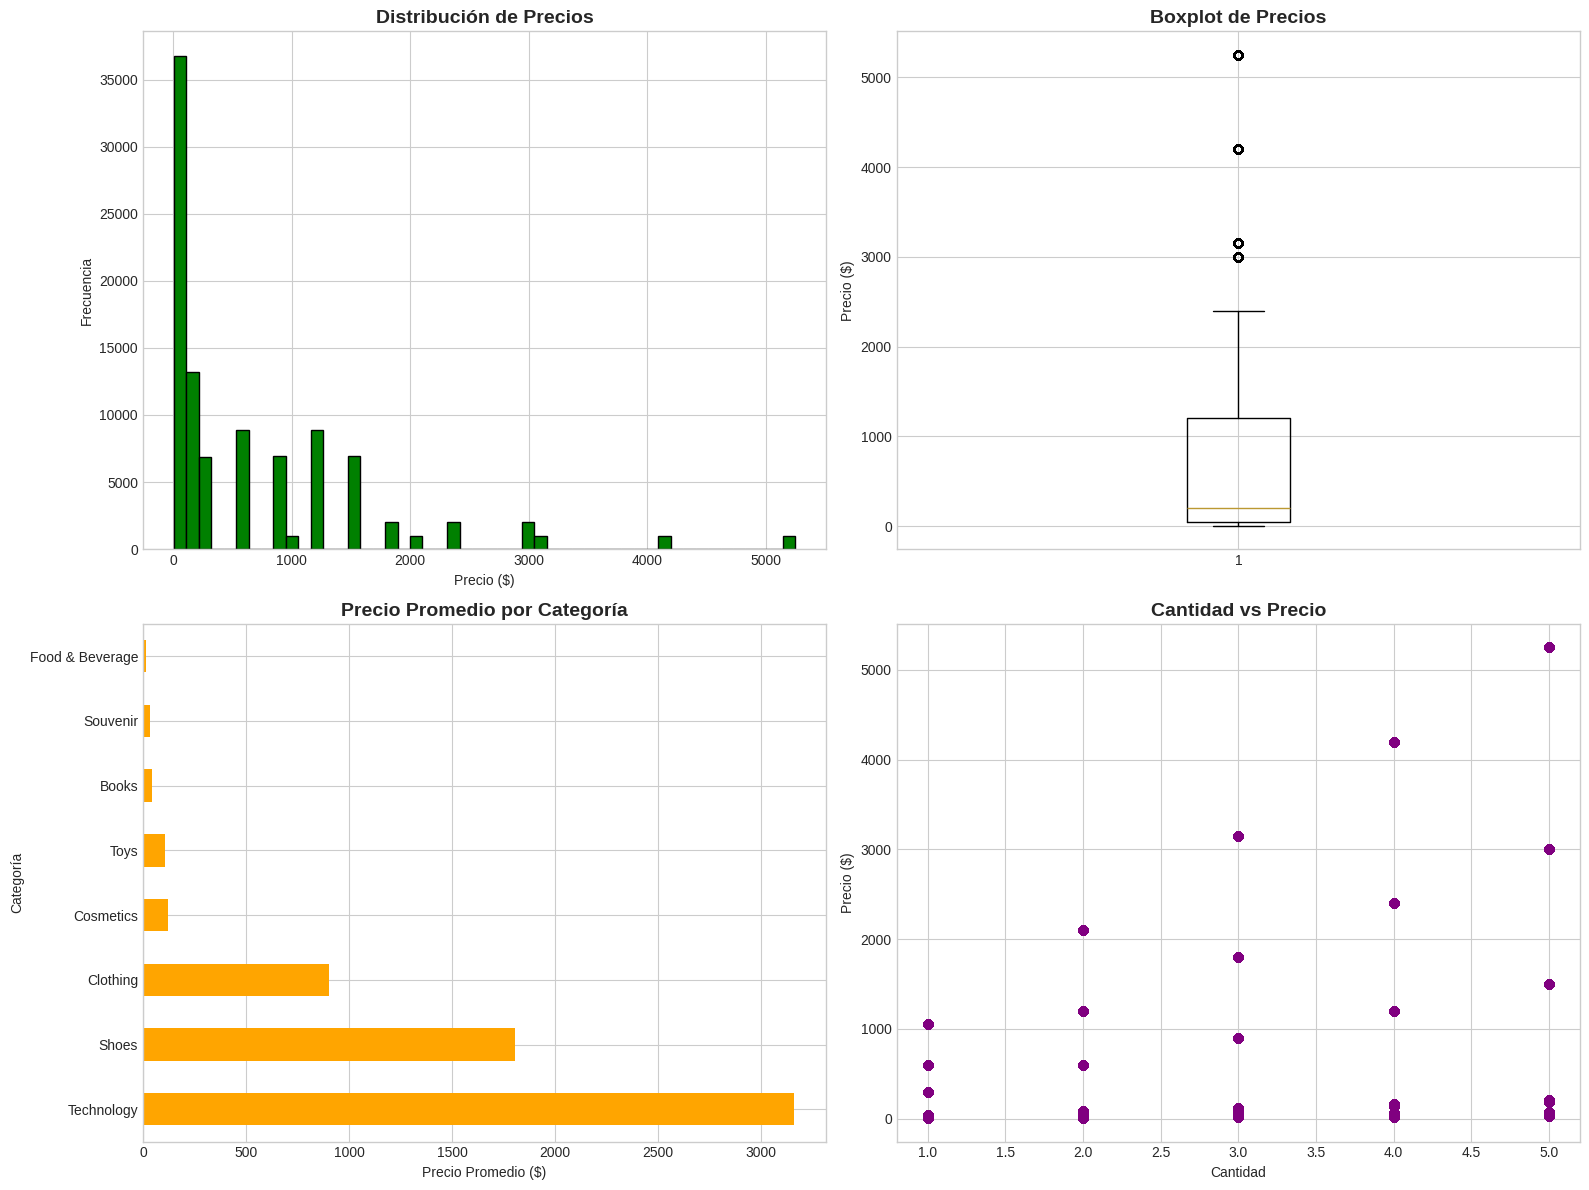


✅ Análisis de precios y cantidades completado


In [13]:
print("="*80)
print("💰 ANÁLISIS DE PRECIOS Y CANTIDADES")
print("="*80)

# 1. PRECIO
print("\n1️⃣ ESTADÍSTICAS DE PRECIO:")
print(f"   • Precio mínimo: ${df['price'].min():.2f}")
print(f"   • Precio máximo: ${df['price'].max():.2f}")
print(f"   • Precio promedio: ${df['price'].mean():.2f}")
print(f"   • Precio mediano: ${df['price'].median():.2f}")

# 2. CANTIDAD
print("\n2️⃣ ESTADÍSTICAS DE CANTIDAD:")
print(f"   • Cantidad mínima: {df['quantity'].min()}")
print(f"   • Cantidad máxima: {df['quantity'].max()}")
print(f"   • Cantidad promedio: {df['quantity'].mean():.2f}")

# 3. PRECIO PROMEDIO POR CATEGORÍA
print("\n3️⃣ PRECIO PROMEDIO POR CATEGORÍA:")
precio_cat = df.groupby('category')['price'].mean().sort_values(ascending=False)
print(precio_cat.round(2))

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma de precios
axes[0,0].hist(df['price'], bins=50, color='green', edgecolor='black')
axes[0,0].set_title('Distribución de Precios', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Precio ($)')
axes[0,0].set_ylabel('Frecuencia')

# Boxplot de precios
axes[0,1].boxplot(df['price'], vert=True)
axes[0,1].set_title('Boxplot de Precios', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Precio ($)')

# Precio promedio por categoría
precio_cat.plot(kind='barh', ax=axes[1,0], color='orange')
axes[1,0].set_title('Precio Promedio por Categoría', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Precio Promedio ($)')
axes[1,0].set_ylabel('Categoría')

# Cantidad vs Precio (scatter)
axes[1,1].scatter(df['quantity'], df['price'], alpha=0.3, color='purple')
axes[1,1].set_title('Cantidad vs Precio', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Cantidad')
axes[1,1].set_ylabel('Precio ($)')

plt.tight_layout()
plt.show()

print("\n✅ Análisis de precios y cantidades completado")

## 📝 CELDA 13: Resumen y Conclusiones de la Exploración

In [14]:
print("="*80)
print("📝 RESUMEN EJECUTIVO - EXPLORACIÓN DATASET PRINCIPAL")
print("="*80)

print("\n✅ DATASET CARGADO Y EXPLORADO EXITOSAMENTE")
print("\n📊 CARACTERÍSTICAS PRINCIPALES:")
print(f"   • Total registros: {len(df):,}")
print(f"   • Período: {df['invoice_date'].min().strftime('%Y-%m-%d')} a {df['invoice_date'].max().strftime('%Y-%m-%d')}")
print(f"   • Categorías productos: {df['category'].nunique()}")
print(f"   • Shopping malls: {df['shopping_mall'].nunique()}")
print(f"   • Métodos de pago: {df['payment_method'].nunique()}")

print("\n🔍 CALIDAD DE DATOS:")
print(f"   • Valores nulos: {df.isnull().sum().sum()}")
print(f"   • Duplicados: {df.duplicated().sum()}")
print("   • Evaluación: ✅ Dataset limpio y listo para integración")

print("\n🎯 PRÓXIMOS PASOS:")
print("   1. ✅ Crear archivo de mapeo Istanbul → España")
print("   2. ⏳ Descargar Open Data del INE (IPC, Población, Comercio)")
print("   3. ⏳ Preparar y limpiar ambos datasets")
print("   4. ⏳ Integrar datasets (LEFT JOIN)")
print("   5. ⏳ Análisis comparativo")
print("   6. ⏳ Visualizaciones finales")

print("\n" + "="*80)
print("🎉 EXPLORACIÓN COMPLETADA - NOTEBOOK 01 FINALIZADO")
print("="*80)

📝 RESUMEN EJECUTIVO - EXPLORACIÓN DATASET PRINCIPAL

✅ DATASET CARGADO Y EXPLORADO EXITOSAMENTE

📊 CARACTERÍSTICAS PRINCIPALES:
   • Total registros: 99,457
   • Período: 2021-01-01 a 2023-03-08
   • Categorías productos: 8
   • Shopping malls: 10
   • Métodos de pago: 3

🔍 CALIDAD DE DATOS:
   • Valores nulos: 0
   • Duplicados: 0
   • Evaluación: ✅ Dataset limpio y listo para integración

🎯 PRÓXIMOS PASOS:
   1. ✅ Crear archivo de mapeo Istanbul → España
   2. ⏳ Descargar Open Data del INE (IPC, Población, Comercio)
   3. ⏳ Preparar y limpiar ambos datasets
   4. ⏳ Integrar datasets (LEFT JOIN)
   5. ⏳ Análisis comparativo
   6. ⏳ Visualizaciones finales

🎉 EXPLORACIÓN COMPLETADA - NOTEBOOK 01 FINALIZADO


---

## 📌 NOTAS IMPORTANTES:

### ✅ Lo que hemos logrado:
- Cargado y explorado dataset principal (99,600+ registros)
- Identificado estructura completa de columnas
- Verificado calidad de datos (sin nulos ni duplicados)
- Analizado distribuciones temporales, categorías, malls
- Preparado mapeo geográfico Istanbul → España

### 🎯 Siguiente Notebook:
**`02_descarga_open_data_ine.ipynb`**
- Descargar IPC por categorías del INE
- Descargar población por CCAA
- Descargar índice comercio minorista
- Preparar Open Data para integración

---